In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib import animation
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split


In [18]:
class Perceptron():  # Perceptron avec y = {-1, 1}
    def __init__(self, p = 0.1, w = None):
        self.biais = 1
        self.p = p
        self.w = np.array(w)
        self.w_history = []
        self.k_history = []

    def predict(self, X):
        return np.sign(X @ self.w[:-1] + self.w[-1])

    def fit(self, X, y):
        x, Y = np.copy(X), np.copy(y)
        x = np.hstack((x, self.biais*np.ones((x.shape[0],1))))
        if self.w is None:
            self.w = [1]*x.shape[1]
        i, j = 0, 0
        while j < len(x) and i <1000:
            j = 0
            for k in range(len(x)):
                if (self.w @ x[k,:]) * Y[k] <  0:
                    #print(self.w)
                    self.w = self.w + self.p * x[k,:] * Y[k]
                    self.w_history.append(self.w.copy())
                    self.k_history.append(k)
                else:
                    j += 1
            i += 1



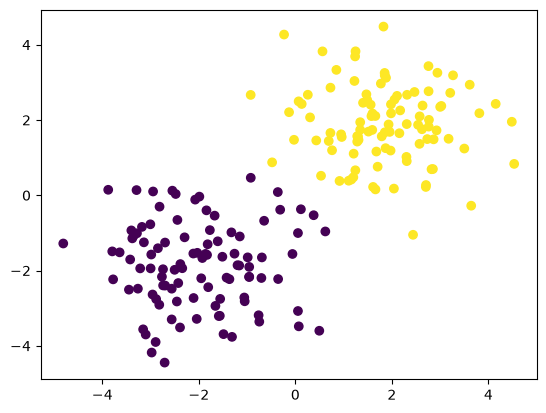

In [4]:
X, y = make_blobs(n_samples=200, centers=[[-2.,-2.],[2.,2.]], cluster_std=[1.1,1.1],
                    n_features=2, random_state=0)
y = y*2 - 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

plt.scatter(X[:,0], X[:,1], c=y)

In [19]:
mod = Perceptron(0.01, [0,0,0.1])
mod.fit(X_train,y_train)
print(mod.w)
yhat = mod.predict(X_test)

print(np.sum(np.sign(yhat) == y_test)/len(y_test)*100, "% de bon classement")

[5.30761292e-02 5.99865404e-02 1.04083409e-17]
100.0 % de bon classement


Pour passer de w à la droite séparatrice :
`w = [w0, w1, b]`  #IcI

Pour un point (x0, x1), le perceptron calcule :
`w0*x0 + w1*x1 + b`

La frontière est l'ensemble de points (x,y) tq :
`w0*x + w1*y + b = 0`
==> `y = - (w0*x + b) / w1`


In [6]:
def animate_perceptron(X, y, w_history, k_history):
    """
    X, y : données (X en 2D)
    w_history : liste des copies de self.w APRES chaque mise à jour
    k_history : liste des index du point qui a déclenché chaque mise à jour
    """
    fig, ax = plt.subplots(figsize=(6,6))
    ax.scatter(X[:,0], X[:,1], c=y, cmap='bwr', alpha=0.6, edgecolors='k')
    line, = ax.plot([], [], 'k-', lw=2)
    highlight = ax.scatter([], [], s=250, facecolors='none', edgecolors='green', linewidths=2.5)

    xmin, xmax = X[:,0].min()-1, X[:,0].max()+1
    ymin, ymax = X[:,1].min()-1, X[:,1].max()+1
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    def update(frame):
        w = w_history[frame]
        k = k_history[frame]
        xs = np.array([xmin, xmax])
        if abs(w[1]) > 1e-8:
            ys = -(w[0]*xs + w[2]) / w[1]
        else:
            ys = np.array([ymin, ymax])  # droite quasi verticale, cas particulier à gérer si tu veux
        line.set_data(xs, ys)
        highlight.set_offsets(X[k].reshape(1, -1))
        ax.set_title(f"Itération {frame+1}/{len(w_history)} — point corrigé : {k}")
        return line, highlight

    ani = animation.FuncAnimation(fig, update, frames=len(w_history), interval=300, blit=False, repeat=False)
    plt.close(fig)
    return HTML(ani.to_jshtml())

In [7]:
animate_perceptron(X_train, y_train, mod.w_history, mod.k_history)